# Phase 2 — stacked ensemble review

Reviews the per-region stacked ensemble (`bagpipe.models.stacked`, built on
the maintainer's [regional-stacker](https://github.com/GalKepler/regional-stacker)
package) on the same subject-grouped CV splits and bias-correction harness
as `baseline_model_demo.ipynb`, so the two are directly comparable. See
`docs/DESIGN.md` §4.1 for the harness design and `CLAUDE.md`'s Phase 2
status note for the model's current standing.

**Feature spec differs by design between the two model families** — this
was a real bug in the first cut of this notebook, caught by the
maintainer: the flat baselines (linear/ridge) get **GM volume only**
(`vol_gm`), one column per region — mixing GM/WM/CSF into one undifferentiated
flat vector would let e.g. a region's WM volume get treated as just another
feature indistinguishable from its GM volume, which isn't a meaningful flat
model. The stacked ensemble gets **all three metrics** (`vol_gm`, `vol_wm`,
`vol_csf`) grouped per region via `region_mapping` — its whole point is
fusing multiple metrics per region through a per-region base learner
*before* flattening to the meta-learner, which also makes per-region
importance inspectable (§4 below).

No subject IDs or raw feature values are printed below — only aggregate
counts and metrics. Outputs are stripped on commit (nbstripout) regardless.

In [1]:
import numpy as np
import pandas as pd

from bagpipe.core.config import REPO_ROOT, get_path
from bagpipe.db.export_training_table import export as export_training_table
from bagpipe.models.tabular import build_region_matrix, build_region_mapping
from bagpipe.models.evaluate import evaluate
from bagpipe.models.bias_correction import get_corrector
from bagpipe.models.covariate_adjustment import TIVSexAdjustedRegressor
from bagpipe.models import baseline, stacked

from regional_stacker import RegionalStackingRegressor
from sklearn.linear_model import LinearRegression, RidgeCV

## 1. Export + build the region-wise feature matrices

Same `globals.parquet`/`regional.parquet` export as the baseline notebook.
`build_region_matrix(..., metrics=...)` filters which per-region measures
go into the flat feature vector: `["vol_gm"]` for the flat baselines,
`["vol_gm", "vol_wm", "vol_csf"]` for the stacked ensemble.
`build_region_mapping` then groups the all-metrics columns into one block
per `atlas__region` — the input `RegionalStackingRegressor` needs for its
per-region base learners.

In [2]:
export_summary = export_training_table()
pd.DataFrame(export_summary).T[["rows"]]

,rows
globals,5664
regional,7877033
image_paths,5653


In [3]:
X_gm, y_gm, groups_gm, region_columns_gm, _sid_gm = build_region_matrix(
    get_path("datasets_dir"), metrics=["vol_gm"]
)
X_all, y_all, groups_all, region_columns_all, _sid_all = build_region_matrix(
    get_path("datasets_dir"), metrics=["vol_gm", "vol_wm", "vol_csf"]
)
region_mapping = build_region_mapping(region_columns_all)

print(
    f"GM-only: {X_gm.shape[0]} samples, {len(region_columns_gm)} region columns\n"
    f"All-metrics: {X_all.shape[0]} samples, {len(region_columns_all)} region columns, "
    f"{len(region_mapping)} distinct regions"
)

GM-only: 5470 samples, 432 region columns
All-metrics: 5470 samples, 1296 region columns, 432 distinct regions


## 2. Run the eval harness — stacked ensemble vs. baselines

Identical grouped-CV split (`n_splits=5`) and Cole bias correction for all
three candidates — the split logic is the same, only the feature spec
differs per model family (see intro), so the leaderboard is still a fair
comparison of *modeling approach*, not of who got more data. The stacked
ensemble is deeper than the baselines (nested CV inside `evaluate`'s own
nested CV for bias correction), so this cell is the slow one — expect
several minutes.

In [4]:
def stacker_fn():
    return RegionalStackingRegressor(
        region_mapping=region_mapping,
        base_estimator=RidgeCV(),
        meta_estimator=RidgeCV(),
        outer_cv=5,
        inner_cv=3,
        n_jobs=-1,
        random_state=0,
    )


candidates = {
    "linear": (lambda: LinearRegression(), X_gm, y_gm, groups_gm),
    "ridge": (lambda: RidgeCV(alphas=np.logspace(-3, 3, 13)), X_gm, y_gm, groups_gm),
    "stacked": (stacker_fn, X_all, y_all, groups_all),
}

results = {}
for name, (base_model_fn, Xc, yc, gc) in candidates.items():
    model_fn = lambda base_model_fn=base_model_fn: TIVSexAdjustedRegressor(base_model_fn)
    results[name] = evaluate(
        model_fn, Xc, yc, gc, n_splits=5, bias_corrector=get_corrector("cole")
    )

In [5]:
leaderboard = pd.DataFrame({name: r.metrics for name, r in results.items()}).T
leaderboard.sort_values("mae_raw")

,mae_raw,mae_corrected,r2_raw,r2_corrected
stacked,4.863699,5.931176,0.677092,0.527537
ridge,5.053192,6.237218,0.657280,0.476858
linear,5.137929,6.314253,0.649774,0.469326


**Known tradeoff, not a bug**: `mae_corrected` is worse than `mae_raw` for
every model here, ridge included. Cole correction is fit to zero out the
BAG-age slope, not to minimize MAE — an affine correction that removes
age-dependent bias necessarily stretches predictions away from the
training-fold mean, which increases MAE on tails. Confirmed in §4 below via
the BAG-vs-age slope check. See `CLAUDE.md` Phase 2 status note.

## 3. Diagnostics — predictions, BAG, distributions, sex differences

Stacked model only, from here on. Same diagnostic battery as the baseline
notebook, for direct visual comparison.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


def build_bag_predictions(result, X, sex_col=-1):
    """`result.predictions` + sex/BAG columns — reusable across model variants
    (old CAT12.9 stacked, CAT26 v26 stacked, v26-with-surface) so the same
    diagnostic plots below apply to any of them, not just one hardcoded run."""
    pred = result.predictions.copy()
    pred["sex"] = X[:, sex_col][pred["index"].to_numpy()]
    pred["sex_label"] = pred["sex"].map({0.0: "Male", 1.0: "Female"})
    pred["bag_raw"] = pred["y_pred_raw"] - pred["y_true"]
    pred["bag_corrected"] = pred["y_pred_corrected"] - pred["y_true"]
    return pred


def plot_pred_vs_true(pred, label):
    fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
    for ax, col, title in zip(
        axes, ["y_pred_raw", "y_pred_corrected"], ["Raw predictions", "Cole-corrected predictions"]
    ):
        ax.scatter(pred["y_true"], pred[col], s=8, alpha=0.3)
        lims = [pred["y_true"].min(), pred["y_true"].max()]
        ax.plot(lims, lims, "k--", lw=1, label="y = x")
        ax.set_xlabel("True age")
        ax.set_ylabel("Predicted age")
        ax.set_title(f"{title} ({label})")
        ax.legend()
    plt.tight_layout()
    plt.show()


def plot_bag_vs_age(pred, label):
    fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
    for ax, col, title in zip(axes, ["bag_raw", "bag_corrected"], ["Raw BAG", "Corrected BAG"]):
        ax.scatter(pred["y_true"], pred[col], s=8, alpha=0.3)
        slope, intercept, r, p, se = stats.linregress(pred["y_true"], pred[col])
        xs = np.array([pred["y_true"].min(), pred["y_true"].max()])
        ax.plot(xs, slope * xs + intercept, "r-", lw=2, label=f"slope={slope:.3f}, p={p:.1e}")
        ax.axhline(0, color="k", lw=1, ls=":")
        ax.set_xlabel("True age")
        ax.set_ylabel("BAG (predicted - true)")
        ax.set_title(f"{title} ({label})")
        ax.legend()
    plt.tight_layout()
    plt.show()


def plot_bag_dist(pred, label):
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.kdeplot(pred["bag_raw"], label="raw", ax=ax)
    sns.kdeplot(pred["bag_corrected"], label="corrected", ax=ax)
    ax.axvline(0, color="k", lw=1, ls=":")
    ax.set_xlabel("BAG (years)")
    ax.set_title(f"BAG distribution ({label})")
    ax.legend()
    plt.show()


def plot_bag_by_sex(pred, label):
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.boxplot(data=pred, x="sex_label", y="bag_corrected", ax=ax)
    sns.stripplot(data=pred, x="sex_label", y="bag_corrected", ax=ax, color="black", alpha=0.15, size=2)
    ax.axhline(0, color="k", lw=1, ls=":")
    ax.set_xlabel("Sex")
    ax.set_ylabel("Corrected BAG (years)")
    ax.set_title(f"Corrected BAG by sex ({label})")
    plt.show()

    male_bag = pred.loc[pred["sex_label"] == "Male", "bag_corrected"]
    female_bag = pred.loc[pred["sex_label"] == "Female", "bag_corrected"]
    u_stat, p_value = stats.mannwhitneyu(male_bag, female_bag)
    print(f"Male:   mean BAG={male_bag.mean():+.2f}y, median={male_bag.median():+.2f}y, n={len(male_bag)}")
    print(f"Female: mean BAG={female_bag.mean():+.2f}y, median={female_bag.median():+.2f}y, n={len(female_bag)}")
    print(f"Mann-Whitney U p-value: {p_value:.4f}")


pred = build_bag_predictions(results["stacked"], X_all)
print(f"{len(pred)} test predictions, stacked model")

5470 test predictions, stacked model


### Predicted vs. true age

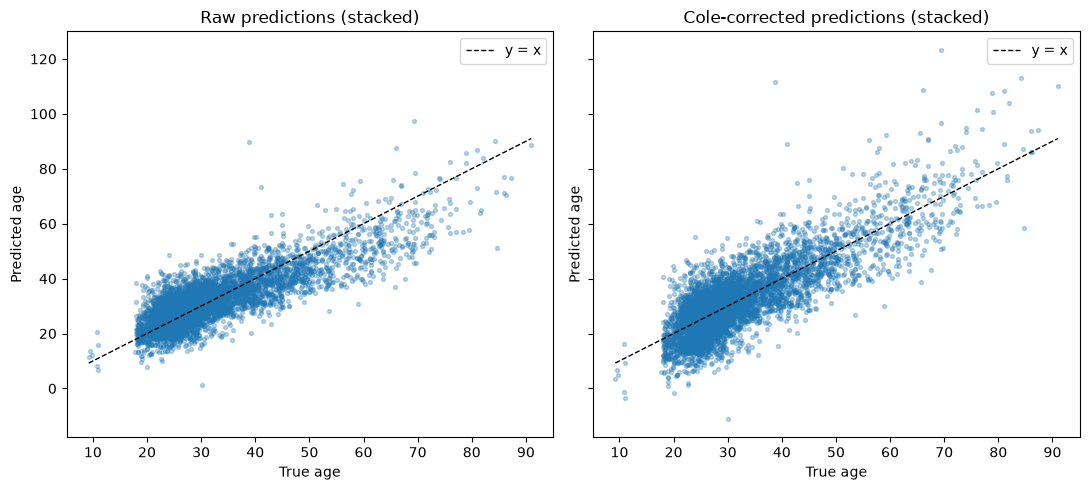

In [7]:
plot_pred_vs_true(pred, "stacked")

### BAG vs. true age — the trend correction should remove

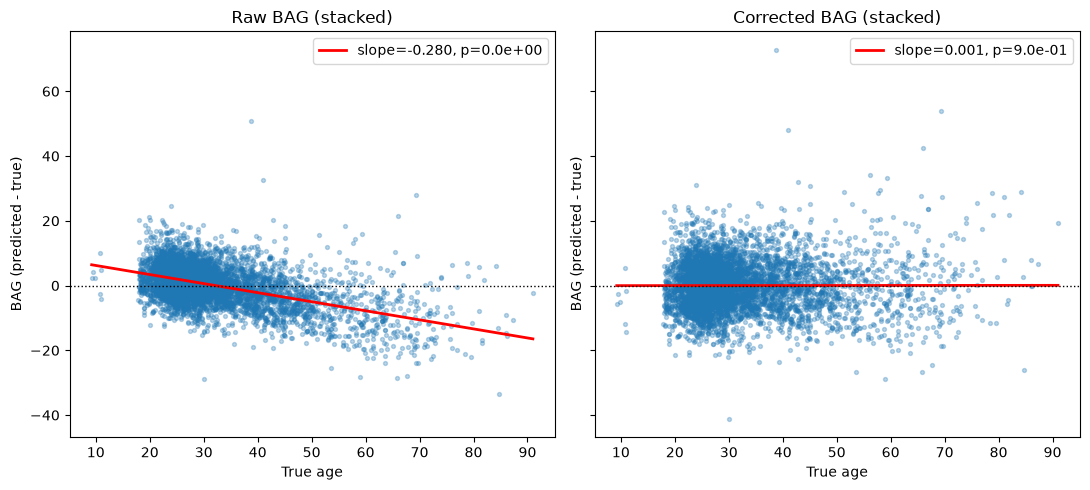

In [8]:
plot_bag_vs_age(pred, "stacked")

### BAG distribution — raw vs. corrected

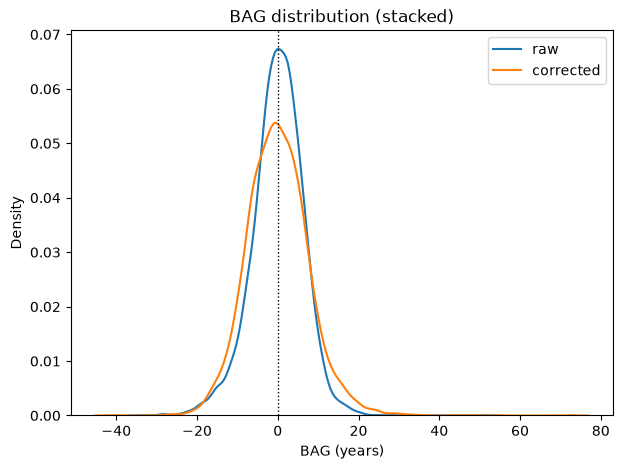

In [9]:
plot_bag_dist(pred, "stacked")

### Corrected BAG by sex

Cole correction is fit on true age only, not sex — a sex gap surviving it is
a genuine model finding, not an artifact of the correction. The ridge model
showed a real gap here (Female positive, Male negative, p<0.0001); worth
checking whether the stacked model reproduces it.

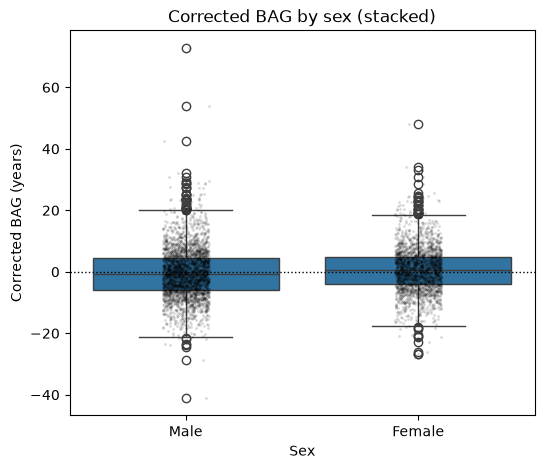

Male:   mean BAG=-0.46y, median=-0.82y, n=3131
Female: mean BAG=+0.61y, median=+0.47y, n=2339
Mann-Whitney U p-value: 0.0000


In [10]:
plot_bag_by_sex(pred, "stacked")

## 4. Per-region diagnostics — what the stacked model gets that ridge doesn't

Fits one stacker on the **full** all-metrics dataset (not the CV harness)
purely to inspect its per-region structure via `regional_stacker`'s fitted
attributes: `region_cv_scores_` (each region's own outer-CV R² as a stage-1
base learner, fit on all three metrics jointly), `meta_best_params_`,
`meta_cv_scores_`. This is an in-sample / exploratory fit for
interpretability only — **not** a held-out metric, don't compare its
numbers to the leaderboard above.

In [ ]:
full_fit = TIVSexAdjustedRegressor(stacker_fn)
full_fit.fit(X_all, y_all)
stacker = full_fit.model_

region_scores = pd.Series(
    {name: scores.mean() for name, scores in stacker.region_cv_scores_.items()}
).sort_values(ascending=False)
print(f"meta-learner outer-CV R²: {stacker.meta_cv_scores_.mean():.3f} (+/- {stacker.meta_cv_scores_.std():.3f})")
print(f"meta-learner best params: {stacker.meta_best_params_}")
region_scores.describe()

### Top / bottom regions by base-learner CV R²

Which regions carry age signal (across GM+WM+CSF jointly) on their own vs.
which are near-noise for the meta-learner to (hopefully) downweight.

In [ ]:
top_n = 20
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
region_scores.head(top_n).iloc[::-1].plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title(f"Top {top_n} regions by base-learner CV R²")
axes[0].set_xlabel("R²")
region_scores.tail(top_n).iloc[::-1].plot.barh(ax=axes[1], color="indianred")
axes[1].set_title(f"Bottom {top_n} regions by base-learner CV R²")
axes[1].set_xlabel("R²")
plt.tight_layout()
plt.show()

## 5. MLflow logging

`stacked.run()` and `baseline.run()` are the config-driven wrappers the CLI
(`bag models train-stacked` / `bag models train-baseline`) calls — same
harness, plus MLflow logging to the shared local tracking store. Each
config now carries its own `features.metrics` (see `config/models/*.yaml`),
so the feature spec used is always logged alongside the metrics, not just
implied by which script ran.

In [ ]:
for module, config_name in [
    (baseline, "baseline_ridge.yaml"),
    (stacked, "stacked.yaml"),
]:
    result, info = module.run(REPO_ROOT / "config" / "models" / config_name)
    print(info["run_name"], {k: round(v, 3) for k, v in result.metrics.items()})

In [ ]:
import mlflow

mlflow.set_tracking_uri(f"sqlite:///{get_path('mlflow_dir') / 'mlflow.db'}")
runs = mlflow.search_runs(experiment_names=["bagpipe-baseline"])
runs[["tags.mlflow.runName", "params.metrics", "metrics.mae_raw", "metrics.mae_corrected", "metrics.r2_corrected"]]

## 6. CAT26 (v26) cohort — leaderboard + same-subject isolation

`config/models/{baseline,stacked,stacked_v26_surface}_v26.yaml` point at
`outputs/datasets_v26` (`bag export training-table --source cat12_v26
--out-dir outputs/datasets_v26`, `features.source="cat12_v26"`) instead of
the production `outputs/datasets` — the CAT26 reprocessing cohort, kept
separate so this never touches the promoted model's dataset. As of
2026-08-24 it's a small, partial cohort (426/~4500 sessions reprocessed,
337 with full age/sex/TIV coverage, 248 with surface output) — its
leaderboard numbers are **not** comparable to the full-cohort production
leaderboard in §2 on their own; the isolation check below is what makes
them comparable.
**Update (2026-08-24)**: full cohort reprocessing (all ~5983 subjects, from scratch,
not just the previously-unprocessed ones) launched in `tmux` session `cat12_cohort_full`
against the rebuilt container — includes the full surface panel (§ below) for every
subject this time, not just the 248-session partial coverage this cell originally described.
Re-run this section once that finishes for a real leaderboard, not the small-n one below.


In [2]:
from bagpipe.db.export_training_table import export as export_training_table_fn

v26_dir = REPO_ROOT / "outputs" / "datasets_v26"
export_summary_v26 = export_training_table_fn(out_dir=v26_dir, source="cat12_v26")
pd.DataFrame(export_summary_v26).T[["rows"]]

,rows
globals,337
regional,562409
image_paths,5653


In [3]:
v26_configs = ["baseline_v26.yaml", "stacked_v26.yaml", "stacked_v26_surface.yaml"]
v26_results = {}
for config_name in v26_configs:
    module = stacked if config_name.startswith("stacked") else baseline
    result, info = module.run(REPO_ROOT / "config" / "models" / config_name)
    v26_results[config_name] = (result, info)
    n_regions = info.get("n_regions", len(info["region_columns"]))
    print(f"{info['run_name']}: n_samples={len(result.predictions)}, n_regions={n_regions}")

v26_leaderboard = pd.DataFrame(
    {name: r.metrics for name, (r, _info) in v26_results.items()}
).T
v26_leaderboard.sort_values("mae_raw")

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/datasets_v26/regional.parquet'

### Same-subject isolation — is CAT26 actually worse, or is this just fewer subjects?

`v26_leaderboard` above will look much worse than §2's full-cohort
leaderboard. Before blaming the new CAT version: re-run the **old**
CAT12.9 GM-only ridge on the *exact same subjects* the v26 cohort covers —
pooling the old `cat12` source restricted to `v26`'s subject_keys, same
row count, same CV size. If the two scores match, the gap in the top-level
leaderboard is a sample-size artifact, not a real regression.

In [ ]:
from bagpipe.models.tabular import SEX_MAP

v26_globals = pd.read_parquet(v26_dir / "globals.parquet")
v26_subjects = v26_globals[["subject_key"]].drop_duplicates()

old_regional = pd.read_parquet(get_path("datasets_dir") / "regional.parquet")
old_globals = pd.read_parquet(get_path("datasets_dir") / "globals.parquet")
old_regional = old_regional[old_regional["metric"] == "vol_gm"].merge(v26_subjects, on="subject_key")
old_globals = old_globals.merge(v26_subjects, on="subject_key")

old_regional = old_regional.copy()
old_regional["region_col"] = old_regional["atlas"] + "__" + old_regional["region"] + "__" + old_regional["metric"]
wide = old_regional.pivot_table(
    index=["subject_key", "session_id"], columns="region_col", values="value"
).reset_index()
region_cols = [c for c in wide.columns if c not in ("subject_key", "session_id")]
cov = old_globals[["subject_key", "session_id", "age", "sex", "TIV"]].copy()
cov["sex"] = cov["sex"].map(SEX_MAP)
table = wide.merge(cov, on=["subject_key", "session_id"], how="inner").dropna(
    subset=["age", "sex", "TIV", *region_cols]
)

X_iso = table[[*region_cols, "TIV", "sex"]].to_numpy(dtype=float)
y_iso = table["age"].to_numpy(dtype=float)
groups_iso = table["subject_key"].to_numpy()

iso_model_fn = lambda: TIVSexAdjustedRegressor(  # noqa: E731
    lambda: RidgeCV(alphas=np.logspace(-3, 3, 13))
)
iso_result = evaluate(iso_model_fn, X_iso, y_iso, groups_iso, n_splits=5, bias_corrector=get_corrector("cole"))

pd.DataFrame(
    {
        "old-cat12 (same subjects)": iso_result.metrics,
        "new-cat12_v26": v26_results["baseline_v26.yaml"][0].metrics,
    }
).T

### Diagnostics — v26 stacked model

Same reusable plot functions from §3, applied to the v26 cohort's stacked
result. `X_all_v26` is rebuilt directly (not via `stacked.run`, which
doesn't return `X`) purely to pull the sex column for `build_bag_predictions`.

In [ ]:
X_all_v26, y_all_v26, groups_all_v26, region_columns_all_v26, _sid_v26 = build_region_matrix(
    v26_dir, metrics=["vol_gm", "vol_wm", "vol_csf"]
)
stacked_v26_result = v26_results["stacked_v26.yaml"][0]
pred_v26 = build_bag_predictions(stacked_v26_result, X_all_v26)
print(f"{len(pred_v26)} test predictions, stacked v26 model")

plot_pred_vs_true(pred_v26, "stacked v26")
plot_bag_vs_age(pred_v26, "stacked v26")
plot_bag_dist(pred_v26, "stacked v26")
plot_bag_by_sex(pred_v26, "stacked v26")

### Full surface panel — gyrification, sulcal depth, fractal dimension, area (2026-08-24)

The gap noted in an earlier version of this cell is closed: `spm.tools.cat.stools.surfextract`
is now wired into `container/cat12.def` as job 2 (chained to segmentation's central-surface
output), computing gyrification index, sulcal depth, fractal dimension, and per-vertex area
alongside thickness for every subject — see `docs/cat12_container_spec.md` §4d for the field
names/values (confirmed against CAT12's real public source after a first guess broke the
whole batch load) and `notebooks/surface_atlas_review.ipynb` §7 for per-metric coverage/
distribution/network-structure plots. `bagpipe.app.surface_atlas.SURFACE_METRICS` and
`bagpipe.app.cat12_parse.SURFACE_METRIC_TAGS` list the five metrics; ingestion
(`bagpipe.db.ingest_cat12_cohort`) already loops all of them into `features`, no ingest-side
change needed once a subject has been reprocessed through the rebuilt container.

**The overfitting risk flagged here previously is real and still applies** — now handled by
`build_region_matrix`'s new `atlases` filter (2026-08-24) rather than by leaving metrics out.
Every surface metric also exists on `surf_DK40`/`surf_Destrieux` (CAT12's own native surface
atlases), not just this cohort's custom Schaefer parcellation — filtering by `metric` alone
(the old approach) pulls all three atlases into one flat matrix, which is what caused the
`stacked_v26_surface` r² collapse this cell used to describe (197 samples vs 1051 regions,
thickness-only). `config/models/stacked_v26_surface.yaml` now sets `features.atlases:
[Schaefer2018N400n7Tian2020S2, surf_Schaefer2018N400n7]` alongside `features.metrics:
[vol_gm, vol_wm, vol_csf, thickness, gyrification, sulcal_depth, fractal_dimension, area]` —
one consistent 400-region parcellation across all 8 metrics, not three parcellations
fighting for the same undersized sample. Re-run §6 below once the full cohort reprocessing
(launched 2026-08-24, `tmux` session `cat12_cohort_full`) has enough coverage — the same
sample-size caveat from §6's isolation check still applies until then.


## Next steps

See the leaderboard in §2 for current MAE numbers — re-run this notebook
for fresh ones rather than trusting stale figures copied into markdown.
Candidates worth trying next: LightGBM or non-linear base learners per
region (captures local nonlinearity ridge can't), a wider `base_param_grid`/
`meta_param_grid` via `stacked.yaml`, and checking whether the bottom-R²
regions above are worth dropping before stage 2. Per `docs/DESIGN.md` §7
Phase 2: SFCN fine-tune once the GPU driver is installed, then promote the
best model to `models_registry` as the v1 production model.